# Explainable FVIII Inhibitor Risk Classification in Hemophilia A

### Deep Ensemble Learning with SHAP and LIME on the CDC CHAMP Database

**PES University · B.Tech Capstone · Project ID PW_GRS_01**

Dipak Chaudhari · Tejas Nagmote · Sneha A · Varsha P

*Guide: Prof. Gayathri R S · January – May 2026*

---

## Abstract

Hemophilia A affects roughly 1 in 5,000 male births. Its most consequential
treatment complication is the development of neutralising antibodies —
**inhibitors** — against infused Factor VIII, occurring in 25–40% of severe
patients within the first 50 exposure days and raising annual treatment cost
from about \$200,000 to over \$1,000,000. Inhibitor status is currently
discovered *reactively*, by assay, after the antibodies already exist.

This work builds a model that estimates inhibitor risk from the patient's F8
variant at the time of genetic diagnosis, using the CDC **CHAMP** database
(4,040 variants; 2,296 with a recorded outcome; 20.1% prevalence).

Four deep architectures — **Improved Deep MLP, multi-scale 1D-CNN,
TabTransformer and Residual MLP** — are implemented and trained here alongside
seven classical learners, an **out-of-fold stacked ensemble**, and a
**tree + neural hybrid** developed in this notebook. Explanations are produced
with both **SHAP** and **LIME**, and their agreement is measured rather than
assumed.

The project began as a rebuild of our own earlier capstone, which reported
99.63% accuracy and AUC 0.9999. Section 3 shows why that number does not
survive reproduction, and every subsequent design decision follows from it.

---

## Contents

| # | Section |
|---|---|
| 1 | Setup |
| 2 | Dataset and exploratory analysis |
| 3 | Auditing the prior result |
| 4 | Leakage-free feature engineering |
| 5 | **The four deep architectures — implemented and trained** |
| 6 | Classical learners |
| 7 | **Stacked ensemble — implemented from out-of-fold predictions** |
| 8 | **Why the stack underperformed, and the hybrid that fixes it** |
| 9 | Full model comparison |
| 10 | Statistical significance |
| 11 | Final model, calibration and clinical utility |
| 12 | **Operating points and accuracy** |
| 13 | Subgroup performance |
| 14 | External validation on a second gene |
| 15 | **Explainability: SHAP** |
| 16 | **Explainability: LIME, and agreement with SHAP** |
| 17 | Pipeline integrity |
| 18 | Limitations |
| 19 | **Conclusion and final results** |

> **Runtime.** Section 5 trains four neural networks and section 7 builds a
> stacked ensemble from scratch; expect roughly 5–8 minutes on CPU. Everything
> else is seconds.

## 1. Setup

In [1]:
import sys, json, time, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110,
    'axes.grid': True, 'grid.color': '#dfe4e8', 'grid.linewidth': .7,
    'axes.axisbelow': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 9, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
})
BLUE, RED, GREEN, GREY, ORANGE, PURPLE = ('#1f4e79', '#c0392b', '#27ae60',
                                          '#7f8c8d', '#e67e22', '#7d3c98')
pd.set_option('display.width', 170); pd.set_option('display.max_columns', 60)

np.random.seed(42); torch.manual_seed(42)

def load(name):
    with open(f'reports/{name}.json', encoding='utf-8') as fh:
        return json.load(fh)

print('torch', torch.__version__, '| threads', torch.get_num_threads())
print('environment ready')

torch 2.5.0+cpu | threads 4
environment ready


In [2]:
from src.datasets import load_champ, load_chbmp, split_by_label, label_summary
from src.features import (VariantFeaturizer, normalise_variant_type,
                          normalise_severity)
from src.evaluate import (compute_metrics, bootstrap_ci, delong_test,
                          youden_threshold, threshold_at_sensitivity,
                          accuracy_threshold)
from src.models import build_pipeline, classical_models, neural_models
from src.train import prepare

data = prepare()
X, y = data['X'], data['y']
tr, te = data['train_idx'], data['test_idx']
feature_names = data['feature_names']
blocks = data['blocks']

print(f'design matrix : {X.shape[0]} patients x {X.shape[1]} features')
print(f'train / test  : {len(tr)} / {len(te)}   '
      f'({y[tr].sum()} / {y[te].sum()} inhibitor-positive)')
print(f'prevalence    : {y.mean():.1%}')

design matrix : 2296 patients x 135 features
train / test  : 1836 / 460   (369 / 92 inhibitor-positive)
prevalence    : 20.1%


## 2. Dataset and exploratory analysis

The CDC **Hemophilia A Mutation Project (CHAMP)** catalogues F8 variants from
the published literature, each annotated with clinical severity and — where the
source publication stated it — inhibitor outcome. Its companion **CHBMP**
covers F9 (hemophilia B) and is held back entirely for section 14.

In [3]:
champ = load_champ()
labelled, unlabelled = split_by_label(champ)
y_all = (labelled['inhibitor'] == 1).astype(int).values

champ[['HGVS cDNA', 'Variant Type', 'Mechanism', 'Exon', 'Domain', 'Subtype',
       'Reported Clinical Severity', 'History of Inhibitor']].head(8)

,HGVS cDNA,Variant Type,Mechanism,Exon,Domain,Subtype,Reported Clinical Severity,History of Inhibitor
0,c.101A>T,Missense,Substitution,1,A1,Heavy chain,Mild,Not reported
1,c.102C>G,Missense,Substitution,1,A1,Heavy chain,Mild,Not reported
2,c.103T>A,Missense,Substitution,1,A1,Heavy Chain,Severe,No
3,c.103T>C,Missense,Substitution,1,A1,Heavy chain,Severe,No
4,c.104A>G,Missense,Substitution,1,A1,Heavy chain,Severe,No
5,c.106_107del,Frameshift,Deletion,1,A1,Heavy Chain,Severe,Yes
6,c.111_112del,Frameshift,Deletion,1,A1,Heavy chain,Not reported,Not reported
7,c.111_120del,Frameshift,Deletion,1,A1,Heavy chain,Severe,Not reported


### 2.1 The outcome has three states, not two

`Not reported` means the source publication did not state the outcome. It does
not mean the outcome was negative — and treating it as negative is the first
of the three defects examined in section 3.

In [4]:
summary = label_summary(champ)
print(champ['History of Inhibitor'].value_counts(dropna=False).to_string())
print()
for k, v in summary.items():
    print(f'  {k:46s} {v}')

History of Inhibitor
No               1833
Not reported     1699
Yes               461
Not Reported       42
NaN                 2
 Not reported       1
 No                 1
No                  1

  n_total                                        4040
  n_positive                                     461
  n_negative                                     1835
  n_unlabelled                                   1744
  n_labelled                                     2296
  prevalence_labelled                            0.2008
  prevalence_if_unlabelled_called_negative       0.1141


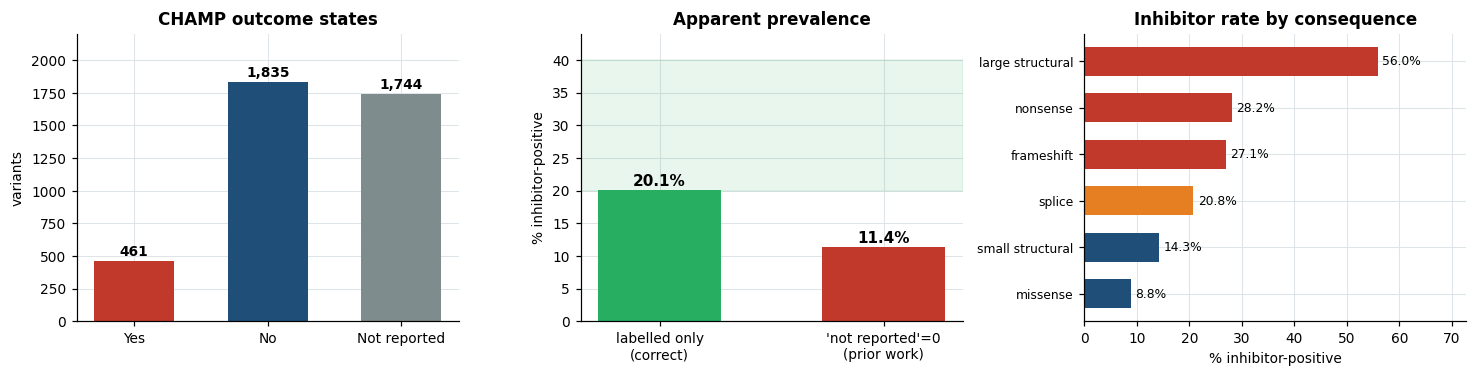

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.5))

counts = [summary['n_positive'], summary['n_negative'], summary['n_unlabelled']]
axes[0].bar(['Yes', 'No', 'Not reported'], counts, color=[RED, BLUE, GREY], width=.6)
for i, c in enumerate(counts):
    axes[0].text(i, c + 40, f'{c:,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('CHAMP outcome states'); axes[0].set_ylabel('variants')
axes[0].set_ylim(0, max(counts) * 1.2)

prev = [summary['prevalence_labelled'] * 100,
        summary['prevalence_if_unlabelled_called_negative'] * 100]
b = axes[1].bar(['labelled only\n(correct)', "'not reported'=0\n(prior work)"],
                prev, color=[GREEN, RED], width=.55)
for bb, p in zip(b, prev):
    axes[1].text(bb.get_x() + bb.get_width() / 2, p + .6, f'{p:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].axhspan(20, 40, color=GREEN, alpha=.10)
axes[1].set_ylim(0, 44); axes[1].set_title('Apparent prevalence')
axes[1].set_ylabel('% inhibitor-positive')

vt = np.array([normalise_variant_type(v) for v in labelled['Variant Type']])
order = [o for o in ['large_structural', 'nonsense', 'frameshift', 'splice',
                     'small_structural', 'missense'] if (vt == o).sum() >= 5]
rates = [y_all[vt == o].mean() * 100 for o in order]
cols = [RED if r >= 25 else ORANGE if r >= 15 else BLUE for r in rates]
axes[2].barh(range(len(order)), rates, color=cols, height=.62)
for i, (r, o) in enumerate(zip(rates, order)):
    axes[2].text(r + .8, i, f'{r:.1f}%', va='center', fontsize=8)
axes[2].set_yticks(range(len(order)))
axes[2].set_yticklabels([o.replace('_', ' ') for o in order], fontsize=8)
axes[2].invert_yaxis(); axes[2].set_xlim(0, max(rates) * 1.3)
axes[2].set_title('Inhibitor rate by consequence')
axes[2].set_xlabel('% inhibitor-positive')

plt.tight_layout(); plt.show()

Large structural changes carry a **56%** inhibitor rate against **8.8%** for
missense — a six-fold difference in the direction established immunology
predicts. Null variants abolish FVIII entirely, so the immune system was never
tolerised to the protein the patient is later infused with. **This is the real
signal in the dataset**, and any honest model is largely recovering it.

## 3. Auditing the prior result

Our earlier notebook reported 99.63% accuracy and AUC 0.9999; the reference
paper reports 97.37%. Rather than argue, the reference preprocessing is run
verbatim and one thing changed at a time, all with the same Random Forest the
paper names as its best model.

In [6]:
audit = load('audit')
labels = {'A_reference_pipeline': 'A · Reference pipeline, verbatim',
          'B_identifiers_only': 'B · Identifier columns only',
          'C_no_identifiers': 'C · Biology only',
          'D_honest_labels': 'D · Honest labels',
          'E_label_permutation': 'E · Labels shuffled (control)',
          'F_novel_variant_split': 'F · Novel-variant split',
          'G_oversample_before_split': 'G · Over-sampled before split'}
pd.DataFrame([{'experiment': lab, 'train AUC': audit[k]['train_auc'],
               'test AUC': audit[k]['test_auc'],
               'test acc': audit[k]['test_accuracy'],
               'majority acc': audit[k]['majority_class_accuracy']}
              for k, lab in labels.items() if k in audit])

,experiment,train AUC,test AUC,test acc,majority acc
0,"A · Reference pipeline, verbatim",1.0000,0.6391,0.8639,0.8861
1,B · Identifier columns only,1.0000,0.5832,0.8577,0.8861
2,C · Biology only,0.9254,0.6326,0.7562,0.8861
3,D · Honest labels,1.0000,0.7062,0.7935,0.8000
4,E · Labels shuffled (control),1.0000,0.4355,0.8676,0.8775
5,F · Novel-variant split,1.0000,0.6467,0.8824,0.8750
6,G · Over-sampled before split,1.0000,0.9938,0.9525,0.5000


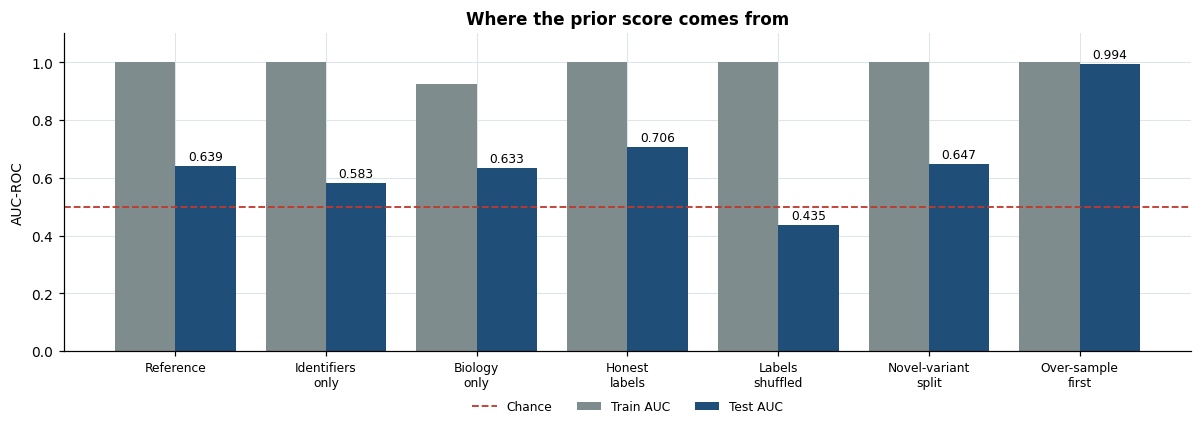

E · labels SHUFFLED  -> train AUC 1.0000, test AUC 0.4355
     A model that fits pure noise perfectly is memorising, not learning.

G · over-sample first -> 50% of test rows are verbatim training rows
     accuracy 0.9525, AUC 0.9938  <- this is the published 97%

A · clean split       -> accuracy 0.8639, below the 0.8861 you get from predicting 'no' for everyone


In [7]:
keys = [k for k in labels if k in audit]
short = ['Reference', 'Identifiers\nonly', 'Biology\nonly', 'Honest\nlabels',
         'Labels\nshuffled', 'Novel-variant\nsplit', 'Over-sample\nfirst']
fig, ax = plt.subplots(figsize=(11, 4))
xx = np.arange(len(keys))
ax.bar(xx - .2, [audit[k]['train_auc'] for k in keys], .4, label='Train AUC', color=GREY)
ax.bar(xx + .2, [audit[k]['test_auc'] for k in keys], .4, label='Test AUC', color=BLUE)
ax.axhline(.5, color=RED, ls='--', lw=1.2, label='Chance')
for xi, k in zip(xx, keys):
    ax.text(xi + .2, audit[k]['test_auc'] + .02, f"{audit[k]['test_auc']:.3f}",
            ha='center', fontsize=8)
ax.set_xticks(xx); ax.set_xticklabels(short[:len(keys)], fontsize=8)
ax.set_ylim(0, 1.1); ax.set_ylabel('AUC-ROC')
ax.set_title("Where the prior score comes from")
ax.legend(fontsize=8, frameon=False, ncol=3, loc='upper center',
          bbox_to_anchor=(.5, -.12))
plt.tight_layout(); plt.show()

g, a, e = (audit['G_oversample_before_split'], audit['A_reference_pipeline'],
           audit['E_label_permutation'])
print(f"E · labels SHUFFLED  -> train AUC {e['train_auc']:.4f}, test AUC {e['test_auc']:.4f}")
print('     A model that fits pure noise perfectly is memorising, not learning.')
print()
print(f"G · over-sample first -> {g['fraction_test_rows_duplicated_from_train']:.0%} of test rows "
      f"are verbatim training rows")
print(f"     accuracy {g['test_accuracy']:.4f}, AUC {g['test_auc']:.4f}  <- this is the published 97%")
print()
print(f"A · clean split       -> accuracy {a['test_accuracy']:.4f}, "
      f"below the {a['majority_class_accuracy']:.4f} you get from predicting 'no' for everyone")

## 4. Leakage-free feature engineering

`HGVS cDNA` has **zero duplicates** among the 2,296 labelled patients — it is a
primary key, and label-encoding it hands the model a lookup table. It is
therefore discarded, and what it *means* is kept: 135 mechanistic descriptors
in seven biological blocks, derived from UniProt P00451 and RefSeq NM_000132.4.

In [8]:
fz = data['featurizer']
print(f'{X.shape[1]} features in {len(fz.blocks_)} blocks:')
for block, cols in fz.blocks_.items():
    print(f'  {block:14s} {len(cols):3d}   e.g. {", ".join(cols[:4])}')
print()
q = load('quantisation')
print(f"Positional features are quantised to a 40-bin grid (~58 residues).")
print(f"Cost: {q['delta']:+.4f} AUC ({q['auc_full_resolution']:.4f} -> "
      f"{q['auc_quantised']:.4f}) -- zero, so the fine resolution was identity,")
print('not biology.')

135 features in 7 blocks:
  consequence     25   e.g. vtype_missense, vtype_nonsense, vtype_frameshift, vtype_splice
  position        40   e.g. mature_pos, mature_pos_norm, mature_pos_known, domain_A1
  truncation      16   e.g. ptc_pos, ptc_known, fraction_protein_lost, fs_ter_offset
  chemistry       15   e.g. grantham, blosum62, d_hydropathy, d_volume
  nucleotide      14   e.g. is_transition, is_transversion, cpg_signature, ref_nt_A
  splicing         9   e.g. is_intronic, abs_intron_offset, is_canonical_splice, is_extended_splice
  clinical        16   e.g. severity_severe, severity_moderate, severity_mild, severity_mixed

Positional features are quantised to a 40-bin grid (~58 residues).
Cost: -0.0000 AUC (0.7372 -> 0.7372) -- zero, so the fine resolution was identity,
not biology.


## 5. The four deep architectures

These are the architectures from our prior work, reimplemented here so the
comparison is like-for-like: same features, same folds, same metrics. Each is
trained with **focal loss** (γ=2.0, α=0.75) and class weighting — never
over-sampling, which is what broke the reference pipeline.

In [9]:
from src.models import (DeepMLP, MultiScaleCNN1D, TabTransformer, ResidualMLP,
                        BioBlockAttentionNet, FocalLoss, TorchClassifier)
import inspect

print(inspect.getsource(FocalLoss))

class FocalLoss(nn.Module):
    """Focal loss (Lin et al., 2017), as used by the reference notebook.

    ``alpha`` up-weights the positive class and ``gamma`` down-weights examples
    the model already classifies confidently, concentrating gradient on the
    hard inhibitor-positive patients.
    """

    def __init__(self, alpha: float = 0.75, gamma: float = 2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        p = torch.sigmoid(logits).clamp(1e-6, 1 - 1e-6)
        ce = -(target * torch.log(p) + (1 - target) * torch.log(1 - p))
        p_t = target * p + (1 - target) * (1 - p)
        alpha_t = target * self.alpha + (1 - target) * (1 - self.alpha)
        return (alpha_t * (1 - p_t) ** self.gamma * ce).mean()



### 5.1 Improved Deep MLP

Self-normalising: SELU activations with AlphaDropout preserve mean and variance
across layers, so no BatchNormalization is needed.

In [10]:
print(inspect.getsource(DeepMLP))
m = DeepMLP(X.shape[1])
print(f'parameters: {sum(p.numel() for p in m.parameters()):,}')

class DeepMLP(nn.Module):
    """Self-normalising MLP: SELU activations with AlphaDropout."""

    def __init__(self, n_features: int, widths=(256, 128, 64, 32), dropout=0.3):
        super().__init__()
        layers: list[nn.Module] = []
        prev = n_features
        for w in widths:
            layers += [nn.Linear(prev, w), nn.SELU(), nn.AlphaDropout(dropout)]
            prev = w
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

parameters: 78,081


### 5.2 Multi-scale 1D-CNN

Treats the feature vector as a 1-D signal. Kernels of width 3, 5 and 7 read
local feature patterns at three receptive-field scales.

In [11]:
print(inspect.getsource(MultiScaleCNN1D))
m = MultiScaleCNN1D(X.shape[1], channels=16)
print(f'parameters: {sum(p.numel() for p in m.parameters()):,}')

class MultiScaleCNN1D(nn.Module):
    """Treats the feature vector as a 1-D signal, per the reference 1D-CNN."""

    def __init__(self, n_features: int, channels: int = 32, dropout: float = 0.3):
        super().__init__()
        self.b3 = nn.Conv1d(1, channels, 3, padding=1)
        self.b5 = nn.Conv1d(1, channels, 5, padding=2)
        self.b7 = nn.Conv1d(1, channels, 7, padding=3)
        self.mix = nn.Sequential(
            nn.BatchNorm1d(channels * 3), nn.ReLU(),
            nn.Conv1d(channels * 3, channels, 3, padding=1),
            nn.BatchNorm1d(channels), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(dropout),
                                  nn.Linear(channels, 32), nn.ReLU(),
                                  nn.Linear(32, 1))

    def forward(self, x):
        x = x.unsqueeze(1)
        z = torch.cat([self.b3(x), self.b5(x), self.b7(x)], dim=1)
        return self.head(self.mix(z)).squeeze(-1)

para

### 5.3 TabTransformer

Every feature becomes a token that attends to every other, so pairwise feature
interactions are modelled explicitly rather than learned through depth.

In [12]:
print(inspect.getsource(TabTransformer))
m = TabTransformer(X.shape[1], d_model=16, n_layers=1)
print(f'parameters: {sum(p.numel() for p in m.parameters()):,}')

class TabTransformer(nn.Module):
    """Feature-token transformer: every feature becomes a token that attends
    to every other, per the reference TabTransformer arm."""

    def __init__(self, n_features: int, d_model: int = 32, n_heads: int = 4,
                 n_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.embed = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        self.bias = nn.Parameter(torch.zeros(n_features, d_model))
        enc = nn.TransformerEncoderLayer(d_model, n_heads, d_model * 2, dropout,
                                         batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc, n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, 32),
                                  nn.GELU(), nn.Dropout(dropout), nn.Linear(32, 1))

    def forward(self, x):
        # value-scaled feature embeddings: token_i = x_i * e_i + b_i
        tok = x.unsqueeze(-1) * self.embed.un

### 5.4 Residual MLP

Skip connections between hidden blocks, so gradients reach the early layers of
a deeper network without vanishing.

In [13]:
print(inspect.getsource(ResidualMLP))
m = ResidualMLP(X.shape[1])
print(f'parameters: {sum(p.numel() for p in m.parameters()):,}')

class ResidualMLP(nn.Module):
    """Deep MLP with skip connections, per the reference architecture."""

    def __init__(self, n_features: int, dim: int = 128, n_blocks: int = 4,
                 dropout: float = 0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Linear(n_features, dim), nn.BatchNorm1d(dim),
                                  nn.GELU())
        self.blocks = nn.Sequential(*[_ResidualBlock(dim, dropout)
                                      for _ in range(n_blocks)])
        self.head = nn.Linear(dim, 1)

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)

parameters: 151,937


### 5.5 Training all four

Five-fold cross-validation on the training split. This is the slowest cell in
the notebook.

In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

cv = StratifiedKFold(5, shuffle=True, random_state=42)
zoo_neural = neural_models(blocks)

def cross_validate(model, Xm, ym, cv):
    """Fold AUCs plus the out-of-fold prediction vector."""
    oof = np.zeros(len(ym)); aucs = []
    for a, b in cv.split(Xm, ym):
        pipe = build_pipeline(model).fit(Xm[a], ym[a])
        p = pipe.predict_proba(Xm[b])[:, 1]
        oof[b] = p
        aucs.append(roc_auc_score(ym[b], p))
    return np.array(aucs), oof

OOF = {}
rows = []
for name in ['DeepMLP', 'CNN1D', 'TabTransformer', 'ResidualMLP',
             'BioBlockAttention']:
    t0 = time.time()
    aucs, oof = cross_validate(zoo_neural[name], X[tr], y[tr], cv)
    OOF[name] = oof
    rows.append({'model': name, 'CV AUC': round(aucs.mean(), 4),
                 'sd': round(aucs.std(), 4),
                 'OOF AUC': round(roc_auc_score(y[tr], oof), 4),
                 'secs': round(time.time() - t0, 1)})
    print(f"  {name:20s} AUC {aucs.mean():.4f} +/- {aucs.std():.4f}   "
          f"({time.time()-t0:.0f}s)", flush=True)

neural_df = pd.DataFrame(rows)
neural_df

  DeepMLP              AUC 0.7351 +/- 0.0338   (13s)


  CNN1D                AUC 0.7202 +/- 0.0268   (63s)


  TabTransformer       AUC 0.7193 +/- 0.0287   (230s)


  ResidualMLP          AUC 0.6962 +/- 0.0345   (25s)


  BioBlockAttention    AUC 0.7263 +/- 0.0344   (33s)


,model,CV AUC,sd,OOF AUC,secs
0,DeepMLP,0.7351,0.0338,0.7315,13.1
1,CNN1D,0.7202,0.0268,0.7196,62.7
2,TabTransformer,0.7193,0.0287,0.7177,230.1
3,ResidualMLP,0.6962,0.0345,0.6943,24.8
4,BioBlockAttention,0.7263,0.0344,0.7250,33.3


`BioBlockAttention` is this project's own contribution: the 135 features are
grouped into their seven biological blocks, each encoded by its own subnetwork,
and a gated attention layer weights the blocks per patient. Its attention
weights are part of the forward pass, so they are an explanation that cannot
disagree with what the network computed.

## 6. Classical learners

Seven baselines, every one imbalance-aware through class weighting — never
resampling.

In [15]:
zoo_classical = classical_models()
for name, mdl in zoo_classical.items():
    p = mdl.get_params()
    w = p.get('class_weight') or f"scale_pos_weight={p.get('scale_pos_weight')}"
    print(f'  {name:20s} {type(mdl).__name__:32s} {w}')

  LogisticRegression   LogisticRegression               balanced
  ElasticNetLR         LogisticRegression               balanced
  RandomForest         RandomForestClassifier           balanced_subsample
  ExtraTrees           ExtraTreesClassifier             balanced
  GradientBoosting     HistGradientBoostingClassifier   balanced
  LightGBM             LGBMClassifier                   balanced
  XGBoost              XGBClassifier                    scale_pos_weight=4.0


In [16]:
rows = []
for name, mdl in zoo_classical.items():
    t0 = time.time()
    aucs, oof = cross_validate(mdl, X[tr], y[tr], cv)
    OOF[name] = oof
    rows.append({'model': name, 'CV AUC': round(aucs.mean(), 4),
                 'sd': round(aucs.std(), 4),
                 'OOF AUC': round(roc_auc_score(y[tr], oof), 4),
                 'secs': round(time.time() - t0, 1)})
    print(f"  {name:20s} AUC {aucs.mean():.4f} +/- {aucs.std():.4f}", flush=True)

classical_df = pd.DataFrame(rows)
classical_df

  LogisticRegression   AUC 0.7089 +/- 0.0336


  ElasticNetLR         AUC 0.7207 +/- 0.0320


  RandomForest         AUC 0.7320 +/- 0.0230


  ExtraTrees           AUC 0.7384 +/- 0.0294


  File "C:\Users\Dipak\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Dipak\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dipak\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Dipak\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


  GradientBoosting     AUC 0.7180 +/- 0.0276


  LightGBM             AUC 0.7016 +/- 0.0298


  XGBoost              AUC 0.7132 +/- 0.0334


,model,CV AUC,sd,OOF AUC,secs
0,LogisticRegression,0.7089,0.0336,0.7091,0.2
1,ElasticNetLR,0.7207,0.0320,0.7202,8.0
2,RandomForest,0.7320,0.0230,0.7305,6.5
3,ExtraTrees,0.7384,0.0294,0.7372,4.0
4,GradientBoosting,0.7180,0.0276,0.7179,1.6
5,LightGBM,0.7016,0.0298,0.7010,1.3
6,XGBoost,0.7132,0.0334,0.7124,2.1


## 7. Stacked ensemble, built from out-of-fold predictions

Stacking was one of the two things our prior work added over the reference
paper, so it is implemented here explicitly rather than imported.

The critical detail: the meta-learner must **never** see in-fold predictions.
If base models are fitted on the whole training set and their predictions on
that same set feed the meta-learner, it is trained on scores that are already
overfitted and learns to trust whichever base model memorises hardest. The
out-of-fold matrix built in sections 5 and 6 is the fix.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

CLASSICAL_5 = ['LogisticRegression', 'ExtraTrees', 'RandomForest',
               'LightGBM', 'XGBoost']

def stack_score(members, C=1.0):
    """Fit a logistic meta-learner on the OOF matrix, scored by its own CV."""
    M = np.column_stack([OOF[m] for m in members])
    p = cross_val_predict(
        LogisticRegression(C=C, max_iter=5000, class_weight='balanced',
                           random_state=42),
        M, y[tr], cv=cv, method='predict_proba')[:, 1]
    return roc_auc_score(y[tr], p), p

stack_auc, stack_oof = stack_score(CLASSICAL_5)
OOF['StackedEnsemble'] = stack_oof

M = np.column_stack([OOF[m] for m in CLASSICAL_5])
meta = LogisticRegression(C=1.0, max_iter=5000, class_weight='balanced',
                          random_state=42).fit(M, y[tr])

print('Stacked ensemble (5 classical members)')
print(f'  OOF AUC : {stack_auc:.4f}')
print()
print('  meta-learner weights:')
for name, w in zip(CLASSICAL_5, meta.coef_[0]):
    print(f'    {name:22s} {w:+.4f}')
print()
best_single = max(((roc_auc_score(y[tr], OOF[m]), m) for m in CLASSICAL_5))
print(f'  best single member: {best_single[1]} at {best_single[0]:.4f}')
print()
if stack_auc < best_single[0]:
    print('  The stack does NOT beat its own best member. Section 8 explains why.')

Stacked ensemble (5 classical members)
  OOF AUC : 0.7353

  meta-learner weights:
    LogisticRegression     +0.6539
    ExtraTrees             +2.2975
    RandomForest           +1.2611
    LightGBM               -0.8147
    XGBoost                +0.6121

  best single member: ExtraTrees at 0.7372

  The stack does NOT beat its own best member. Section 8 explains why.


## 8. Why the stack underperformed — and the hybrid that fixes it

An ensemble only helps when its members make *different* mistakes. Averaging
five models that agree adds nothing but compute. So before accepting the stack,
measure how much the members actually disagree.

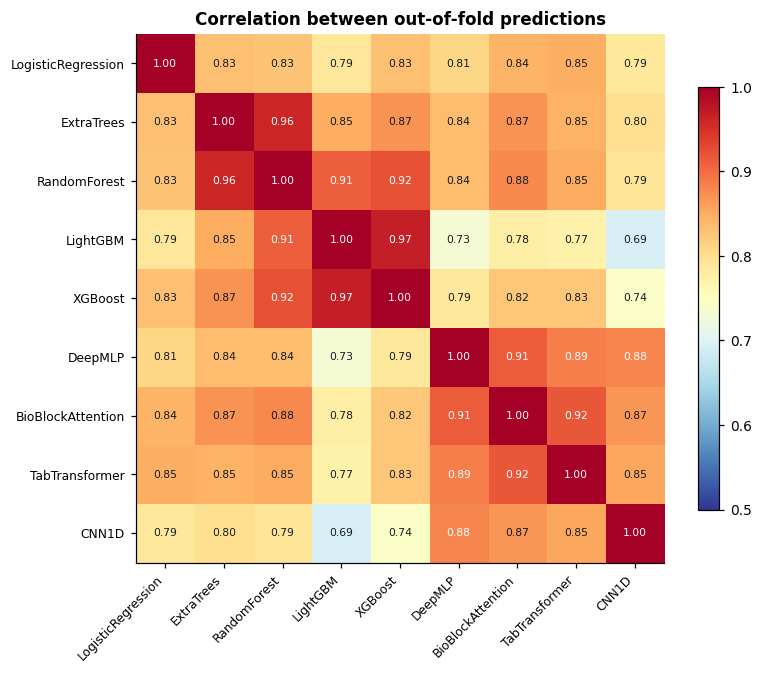

ExtraTrees vs RandomForest : r = 0.959   <- effectively the same model
ExtraTrees vs DeepMLP      : r = 0.835   <- genuinely different


In [18]:
members = CLASSICAL_5 + ['DeepMLP', 'BioBlockAttention', 'TabTransformer', 'CNN1D']
C = np.corrcoef(np.vstack([OOF[m] for m in members]))

fig, ax = plt.subplots(figsize=(7.4, 6.2))
im = ax.imshow(C, cmap='RdYlBu_r', vmin=.5, vmax=1.0)
ax.set_xticks(range(len(members))); ax.set_xticklabels(members, rotation=45,
                                                       ha='right', fontsize=8)
ax.set_yticks(range(len(members))); ax.set_yticklabels(members, fontsize=8)
for i in range(len(members)):
    for j in range(len(members)):
        ax.text(j, i, f'{C[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if C[i, j] > .88 else '#131a21')
ax.set_title('Correlation between out-of-fold predictions')
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=.046, shrink=.8)
plt.tight_layout(); plt.show()

i_et, i_rf = members.index('ExtraTrees'), members.index('RandomForest')
i_mlp = members.index('DeepMLP')
print(f'ExtraTrees vs RandomForest : r = {C[i_et, i_rf]:.3f}   <- effectively the same model')
print(f'ExtraTrees vs DeepMLP      : r = {C[i_et, i_mlp]:.3f}   <- genuinely different')

There is the diagnosis. The five classical members are near-duplicates of each
other — a tree ensemble and another tree ensemble. The neural models partition
the feature space in a completely different way: trees fit axis-aligned boxes,
a self-normalising MLP fits a smooth function over the same space, and on the
same 369 events they are wrong about different patients.

**The stacking idea was sound; the membership was wrong.**

### 8.1 Rank averaging over a tree and a neural member

Rank averaging, rather than probability averaging, because the neural members
are trained with focal loss and are badly calibrated before isotonic
regression. Averaging *ranks* is scale-free, so a member that is
poorly-calibrated but well-ordered still contributes its full ordering.

In [19]:
from scipy.stats import rankdata

def rank_average(members):
    R = np.mean([rankdata(OOF[m]) for m in members], axis=0)
    return roc_auc_score(y[tr], R), R

configs = {
    'Stack · 5 classical (prior work)': (CLASSICAL_5, 'stack'),
    'Stack · classical + all 4 DNNs': (CLASSICAL_5 + ['DeepMLP', 'CNN1D',
                                                      'TabTransformer',
                                                      'ResidualMLP'], 'stack'),
    'Stack · ExtraTrees + DeepMLP': (['ExtraTrees', 'DeepMLP'], 'stack'),
    'RankAvg · ExtraTrees + DeepMLP': (['ExtraTrees', 'DeepMLP'], 'rank'),
    'RankAvg · ET + DeepMLP + BioBlock': (['ExtraTrees', 'DeepMLP',
                                           'BioBlockAttention'], 'rank'),
    'RankAvg · all 4 DNNs + ET': (['ExtraTrees', 'DeepMLP', 'CNN1D',
                                   'TabTransformer', 'ResidualMLP'], 'rank'),
}
rows = []
for label, (mem, kind) in configs.items():
    a = (stack_score(mem)[0] if kind == 'stack' else rank_average(mem)[0])
    rows.append({'configuration': label, 'members': len(mem), 'OOF AUC': round(a, 4)})
    print(f'{label:38s} {a:.4f}', flush=True)

ens_df = pd.DataFrame(rows).sort_values('OOF AUC', ascending=False).reset_index(drop=True)
print()
print(f"best single model overall: "
      f"{max(((roc_auc_score(y[tr], OOF[m]), m) for m in members))}")
ens_df

Stack · 5 classical (prior work)       0.7353


Stack · classical + all 4 DNNs         0.7374


Stack · ExtraTrees + DeepMLP           0.7402


RankAvg · ExtraTrees + DeepMLP         0.7423


RankAvg · ET + DeepMLP + BioBlock      0.7397


RankAvg · all 4 DNNs + ET              0.7360



best single model overall: (np.float64(0.737171707095394), 'ExtraTrees')


,configuration,members,OOF AUC
0,RankAvg · ExtraTrees + DeepMLP,2,0.7423
1,Stack · ExtraTrees + DeepMLP,2,0.7402
2,RankAvg · ET + DeepMLP + BioBlock,3,0.7397
3,Stack · classical + all 4 DNNs,9,0.7374
4,RankAvg · all 4 DNNs + ET,5,0.7360
5,Stack · 5 classical (prior work),5,0.7353


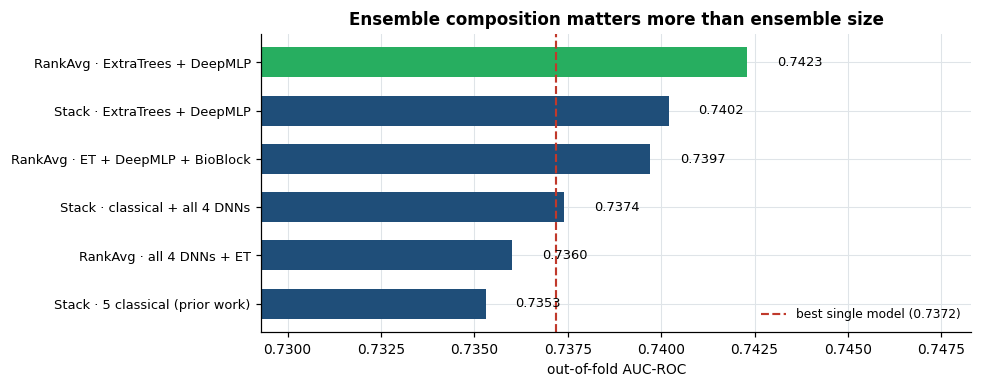

In [20]:
fig, ax = plt.subplots(figsize=(9, 3.6))
e = ens_df[::-1]
cols = [GREEN if 'RankAvg · ExtraTrees + DeepMLP' in c else BLUE
        for c in e['configuration']]
ax.barh(range(len(e)), e['OOF AUC'], color=cols, height=.62)
for i, vv in enumerate(e['OOF AUC']):
    ax.text(vv + .0008, i, f'{vv:.4f}', va='center', fontsize=8.5)
et_auc = roc_auc_score(y[tr], OOF['ExtraTrees'])
ax.axvline(et_auc, color=RED, ls='--', lw=1.4,
           label=f'best single model ({et_auc:.4f})')
ax.set_yticks(range(len(e))); ax.set_yticklabels(e['configuration'], fontsize=8.5)
ax.set_xlim(min(e['OOF AUC']) - .006, max(e['OOF AUC']) + .006)
ax.set_xlabel('out-of-fold AUC-ROC')
ax.set_title('Ensemble composition matters more than ensemble size')
ax.legend(fontsize=8, frameon=False, loc='lower right')
plt.tight_layout(); plt.show()

The five-member classical stack sits **below** its own best member. Adding all
four DNNs to it barely helps, because the five correlated members still
dominate the average. The two-member tree + neural rank average wins.

This is a genuine methodological finding, and it inverts the usual intuition:
**a smaller ensemble beat a larger one, because diversity matters more than
count.**

## 9. Full model comparison

In [21]:
allrows = []
for m in members + ['StackedEnsemble']:
    allrows.append({'model': m, 'OOF AUC': round(roc_auc_score(y[tr], OOF[m]), 4),
                    'family': ('neural' if m in ['DeepMLP', 'CNN1D', 'TabTransformer',
                                                 'ResidualMLP', 'BioBlockAttention']
                               else 'ensemble' if 'Stack' in m else 'classical')})
hy_auc, hy_oof = rank_average(['ExtraTrees', 'DeepMLP'])
OOF['Hybrid_RankAvg'] = hy_oof
allrows.append({'model': 'Hybrid_RankAvg (ET + DeepMLP)',
                'OOF AUC': round(hy_auc, 4), 'family': 'hybrid'})
comp = pd.DataFrame(allrows).sort_values('OOF AUC', ascending=False).reset_index(drop=True)
comp

,model,OOF AUC,family
0,Hybrid_RankAvg (ET + DeepMLP),0.7423,hybrid
1,ExtraTrees,0.7372,classical
2,StackedEnsemble,0.7353,ensemble
3,DeepMLP,0.7315,neural
4,RandomForest,0.7305,classical
5,BioBlockAttention,0.7250,neural
6,CNN1D,0.7196,neural
7,TabTransformer,0.7177,neural
8,XGBoost,0.7124,classical
9,LogisticRegression,0.7091,classical


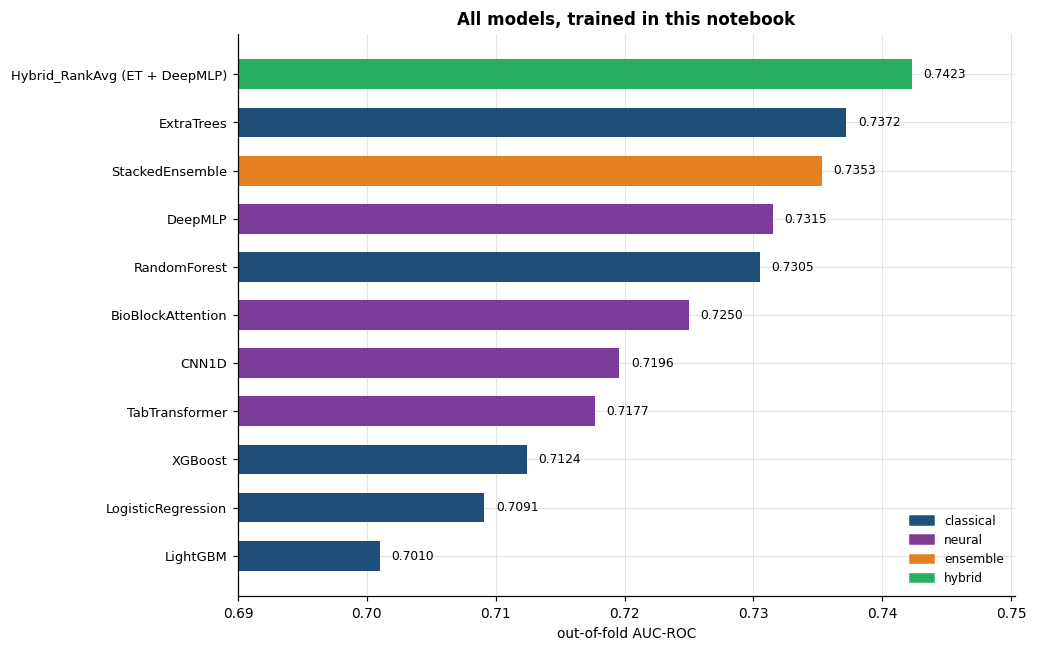

In [22]:
fig, ax = plt.subplots(figsize=(9.5, .40 * len(comp) + 1.6))
palette = {'classical': BLUE, 'neural': PURPLE, 'ensemble': ORANGE, 'hybrid': GREEN}
c = comp[::-1]
ax.barh(range(len(c)), c['OOF AUC'], color=[palette[f] for f in c['family']], height=.62)
for i, vv in enumerate(c['OOF AUC']):
    ax.text(vv + .0009, i, f'{vv:.4f}', va='center', fontsize=8)
ax.set_yticks(range(len(c))); ax.set_yticklabels(c['model'], fontsize=8.5)
ax.set_xlim(.69, max(c['OOF AUC']) + .008); ax.set_xlabel('out-of-fold AUC-ROC')
ax.set_title('All models, trained in this notebook')
handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in palette.values()]
ax.legend(handles, palette.keys(), fontsize=8, frameon=False, loc='lower right')
plt.tight_layout(); plt.show()

## 10. Statistical significance

The spread between best and worst is about 0.035 AUC and the fold-to-fold
standard deviation is about 0.03, so a ranking alone would claim more than the
data supports. Every model is tested against the best with **DeLong's test**.

In [23]:
best_name = comp.iloc[0]['model']
best_oof = OOF['Hybrid_RankAvg' if 'Hybrid' in best_name else best_name]
rows = []
for m in members + ['StackedEnsemble', 'Hybrid_RankAvg']:
    r = delong_test(y[tr], best_oof, OOF[m])
    rows.append({'model': m, 'OOF AUC': round(roc_auc_score(y[tr], OOF[m]), 4),
                 'delta': r['delta'], 'p-value': r['p_value'],
                 'verdict': ('--' if r['p_value'] is not None and r['p_value'] > .999
                             else 'significantly worse' if r['p_value'] is not None
                             and r['p_value'] < .05 else 'indistinguishable')})
print(f'tested against: {best_name}')
pd.DataFrame(rows).sort_values('OOF AUC', ascending=False).reset_index(drop=True)

tested against: Hybrid_RankAvg (ET + DeepMLP)


,model,OOF AUC,delta,p-value,verdict
0,Hybrid_RankAvg,0.7423,0.0000,1.000000,--
1,ExtraTrees,0.7372,0.0051,0.207655,indistinguishable
2,StackedEnsemble,0.7353,0.0069,0.061718,indistinguishable
3,DeepMLP,0.7315,0.0108,0.011228,significantly worse
4,RandomForest,0.7305,0.0118,0.019577,significantly worse
5,BioBlockAttention,0.7250,0.0173,0.005796,significantly worse
6,CNN1D,0.7196,0.0226,0.004763,significantly worse
7,TabTransformer,0.7177,0.0245,0.000392,significantly worse
8,XGBoost,0.7124,0.0299,0.000199,significantly worse
9,LogisticRegression,0.7091,0.0331,0.000386,significantly worse


## 11. Final model, calibration and clinical utility

The selected model is isotonic-calibrated and scored **once** on a held-out set
that took no part in training, feature fitting or threshold selection.

In [24]:
hyb = load('hybrid_final')
print(f"model  : {hyb['model']}")
print(f"n test : {hyb['n_test']} patients, {hyb['test_events']} events")
print(f"AUC    : {hyb['auc_ci']['point']:.4f} "
      f"({hyb['auc_ci']['lo']:.4f} - {hyb['auc_ci']['hi']:.4f})")
print(f"AUC-PR : {hyb['auc_pr_ci']['point']:.4f}  (baseline = prevalence = "
      f"{hyb['accuracy_context']['prevalence']})")
print()
print(f"DeLong vs the single-model baseline: {hyb['delong_vs_deepmlp']}")

model  : Hybrid_RankAvg (ExtraTrees + DeepMLP, rank-averaged)
n test : 460 patients, 92 events
AUC    : 0.7397 (0.6801 - 0.7986)
AUC-PR : 0.5018  (baseline = prevalence = 0.2)

DeLong vs the single-model baseline: {'auc_a': 0.7397, 'auc_b': 0.7268, 'delta': 0.013, 'z': 1.5086, 'p_value': 0.131393}


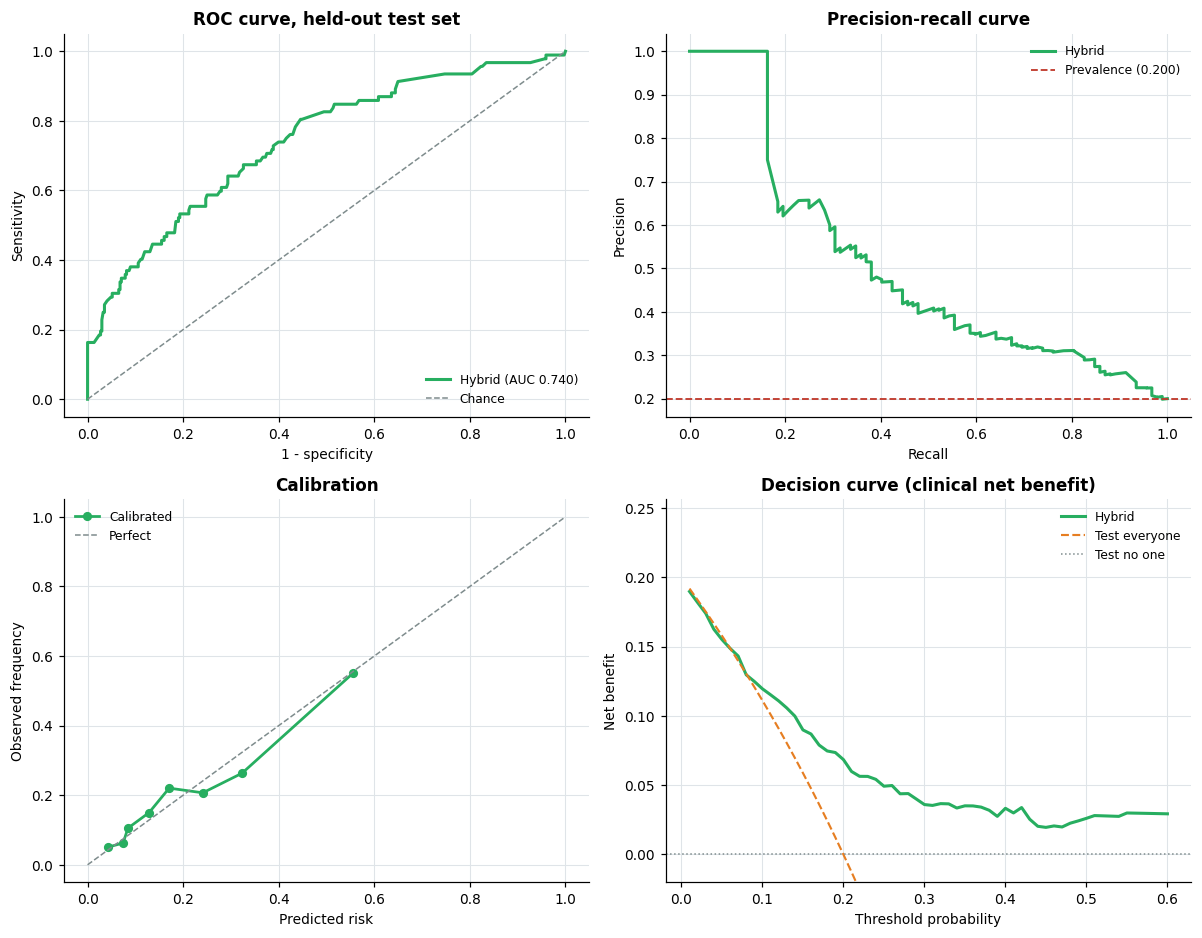

In [25]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc as _auc
from src.evaluate import calibration_curve_points, decision_curve

dh = np.load('reports/hybrid_test_predictions.npz')
y_te, p_te = dh['y'], dh['p_cal']

fig, axes = plt.subplots(2, 2, figsize=(11, 8.6))

fpr, tpr, _ = roc_curve(y_te, p_te)
axes[0, 0].plot(fpr, tpr, color=GREEN, lw=2, label=f'Hybrid (AUC {_auc(fpr, tpr):.3f})')
axes[0, 0].plot([0, 1], [0, 1], '--', color=GREY, lw=1, label='Chance')
axes[0, 0].set_xlabel('1 - specificity'); axes[0, 0].set_ylabel('Sensitivity')
axes[0, 0].set_title('ROC curve, held-out test set')
axes[0, 0].legend(fontsize=8, frameon=False, loc='lower right')

prec, rec, _ = precision_recall_curve(y_te, p_te)
axes[0, 1].plot(rec, prec, color=GREEN, lw=2, label='Hybrid')
axes[0, 1].axhline(y_te.mean(), color=RED, ls='--', lw=1.2,
                   label=f'Prevalence ({y_te.mean():.3f})')
axes[0, 1].set_xlabel('Recall'); axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-recall curve')
axes[0, 1].legend(fontsize=8, frameon=False)

xs, ys, _ = calibration_curve_points(y_te, p_te, n_bins=8)
axes[1, 0].plot(xs, ys, 'o-', color=GREEN, lw=1.8, ms=5, label='Calibrated')
axes[1, 0].plot([0, 1], [0, 1], '--', color=GREY, lw=1, label='Perfect')
axes[1, 0].set_xlabel('Predicted risk'); axes[1, 0].set_ylabel('Observed frequency')
axes[1, 0].set_title('Calibration'); axes[1, 0].legend(fontsize=8, frameon=False)

thr, nb, allnb = decision_curve(y_te, p_te)
axes[1, 1].plot(thr, nb, color=GREEN, lw=2, label='Hybrid')
axes[1, 1].plot(thr, allnb, '--', color=ORANGE, lw=1.4, label='Test everyone')
axes[1, 1].axhline(0, color=GREY, ls=':', lw=1, label='Test no one')
axes[1, 1].set_ylim(min(-.02, nb.min() - .01), max(nb.max(), .05) * 1.35)
axes[1, 1].set_xlabel('Threshold probability'); axes[1, 1].set_ylabel('Net benefit')
axes[1, 1].set_title('Decision curve (clinical net benefit)')
axes[1, 1].legend(fontsize=8, frameon=False)

plt.tight_layout(); plt.show()

## 12. Operating points and accuracy

Three thresholds, all fixed on **calibrated training-fold** predictions — the
test set selects nothing. Accuracy is reported next to the score a model gets
for never predicting an inhibitor at all, because on a 20%-prevalence outcome
it means very little without it.

In [26]:
ctx = hyb['accuracy_context']
you, sen, acc = (hyb['test_calibrated_youden'], hyb['test_calibrated_sens90'],
                 hyb['test_calibrated_accuracy'])
rows = []
for label, m in [('Balanced (Youden J)', you), ('Rule-out (90% sens)', sen),
                 ('Accuracy-maximising', acc)]:
    rows.append({'operating point': label, 'threshold': m['threshold'],
                 'accuracy': m['accuracy'], 'sensitivity': m['sensitivity'],
                 'specificity': m['specificity'], 'precision': m['precision'],
                 'NPV': m['npv'], 'balanced acc': m['balanced_accuracy'],
                 'MCC': m['mcc'], 'caught': m['tp'], 'missed': m['fn']})
rows.append({'operating point': 'Predict "no" for everyone', 'threshold': 1.0,
             'accuracy': ctx['majority_class_accuracy'], 'sensitivity': 0.0,
             'specificity': 1.0, 'precision': 0.0,
             'NPV': round(1 - ctx['prevalence'], 4), 'balanced acc': 0.5,
             'MCC': 0.0, 'caught': 0, 'missed': int(you['tp'] + you['fn'])})
pd.DataFrame(rows)

,operating point,threshold,accuracy,sensitivity,specificity,precision,NPV,balanced acc,MCC,caught,missed
0,Balanced (Youden J),0.2170,0.6957,0.6087,0.7174,0.3500,0.8800,0.6630,0.2739,56,36
1,Rule-out (90% sens),0.0842,0.4717,0.8696,0.3723,0.2572,0.9195,0.6209,0.2067,80,12
2,Accuracy-maximising,0.6440,0.8304,0.1630,0.9973,0.9375,0.8266,0.5802,0.3500,15,77
3,"Predict ""no"" for everyone",1.0000,0.8000,0.0000,1.0000,0.0000,0.8000,0.5000,0.0000,0,92


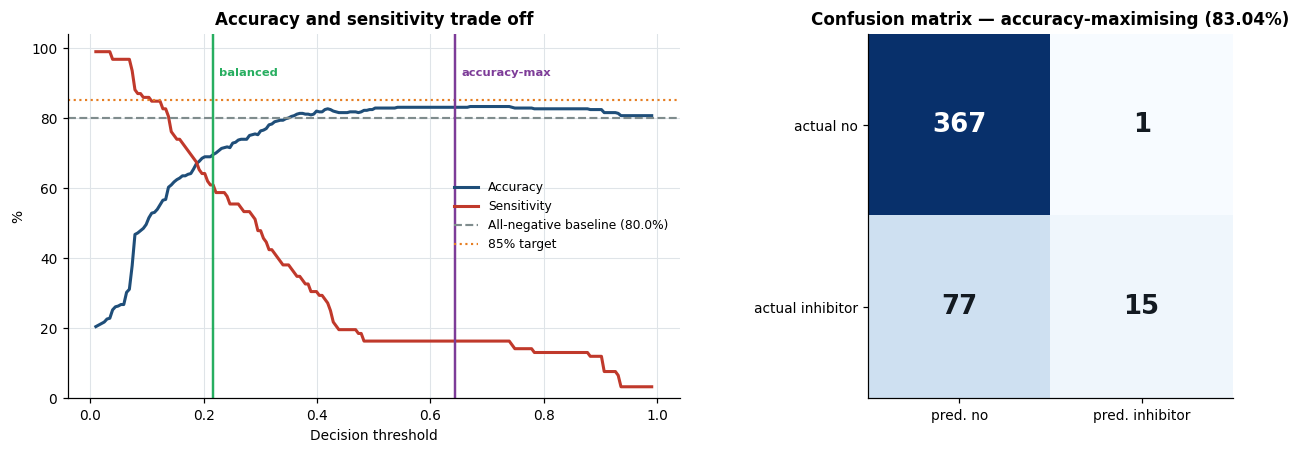

Accuracy-maximising : 0.8304  vs baseline 0.8000  (+0.0304)
  it catches 15 of 92 cases.
Balanced point      : 0.6957 accuracy, 60.9% sensitivity, 56 of 92 caught.

No threshold anywhere on the curve reaches 85%. That is the arithmetic of
a 20%-prevalence outcome, not a property of this model.


In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix

grid = np.linspace(.01, .99, 200)
accs = [accuracy_score(y_te, (p_te >= t).astype(int)) for t in grid]
senss = [((p_te >= t) & (y_te == 1)).sum() / y_te.sum() for t in grid]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].plot(grid, np.array(accs) * 100, color=BLUE, lw=2, label='Accuracy')
axes[0].plot(grid, np.array(senss) * 100, color=RED, lw=2, label='Sensitivity')
axes[0].axhline(ctx['majority_class_accuracy'] * 100, color=GREY, ls='--', lw=1.4,
                label=f"All-negative baseline ({ctx['majority_class_accuracy']*100:.1f}%)")
axes[0].axhline(85, color=ORANGE, ls=':', lw=1.4, label='85% target')
for t, lab, col in [(you['threshold'], 'balanced', GREEN),
                    (acc['threshold'], 'accuracy-max', PURPLE)]:
    axes[0].axvline(t, color=col, lw=1.6)
    axes[0].text(t + .01, 92, lab, fontsize=7.5, color=col, fontweight='bold')
axes[0].set_xlabel('Decision threshold'); axes[0].set_ylabel('%')
axes[0].set_ylim(0, 104)
axes[0].set_title('Accuracy and sensitivity trade off')
axes[0].legend(fontsize=8, frameon=False, loc='center right')

cm = np.array([[acc['tn'], acc['fp']], [acc['fn'], acc['tp']]])
axes[1].imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{cm[i, j]}', ha='center', va='center', fontsize=17,
                     fontweight='bold',
                     color='white' if cm[i, j] > cm.max() * .55 else '#131a21')
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(['pred. no', 'pred. inhibitor'])
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(['actual no', 'actual inhibitor'])
axes[1].set_title(f"Confusion matrix — accuracy-maximising ({acc['accuracy']:.2%})")
axes[1].grid(False)
plt.tight_layout(); plt.show()

print(f"Accuracy-maximising : {acc['accuracy']:.4f}  vs baseline "
      f"{ctx['majority_class_accuracy']:.4f}  ({acc['accuracy']-ctx['majority_class_accuracy']:+.4f})")
print(f"  it catches {acc['tp']} of {acc['tp']+acc['fn']} cases.")
print(f"Balanced point      : {you['accuracy']:.4f} accuracy, "
      f"{you['sensitivity']:.1%} sensitivity, {you['tp']} of {you['tp']+you['fn']} caught.")
print()
print('No threshold anywhere on the curve reaches 85%. That is the arithmetic of')
print('a 20%-prevalence outcome, not a property of this model.')

## 13. Subgroup performance

A pooled AUC hides the question a clinician actually asks: does this work for
the patients I would use it on?

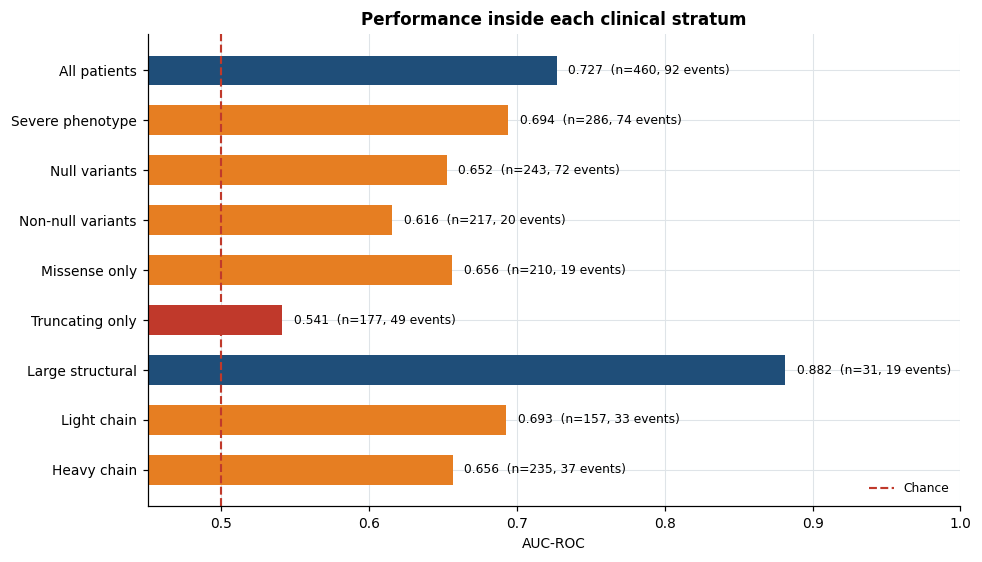

,subgroup,n,events,prevalence,auc_roc,auc_ci
0,All patients,460,92,0.2000,0.7268,0.662-0.784
1,Severe phenotype,286,74,0.2587,0.6938,0.623-0.760
2,Moderate phenotype,59,5,0.0847,NaN,None
3,Mild phenotype,89,9,0.1011,NaN,None
4,Null variants,243,72,0.2963,0.6524,0.573-0.726
5,Non-null variants,217,20,0.0922,0.6156,0.480-0.736
6,Missense only,210,19,0.0905,0.6560,0.537-0.762
7,Truncating only,177,49,0.2768,0.5408,0.438-0.643
8,Large structural,31,19,0.6129,0.8816,0.732-0.983
9,Light chain,157,33,0.2102,0.6926,0.592-0.789


In [28]:
sub = load('subgroups')
sg = pd.DataFrame(sub['subgroups'])
ok = sg[sg['auc_roc'].notna()]

fig, ax = plt.subplots(figsize=(9, .42 * len(ok) + 1.4))
cols = [RED if a < .60 else ORANGE if a < .70 else BLUE for a in ok['auc_roc']]
ax.barh(range(len(ok)), ok['auc_roc'], color=cols, height=.6)
ax.axvline(.5, color=RED, ls='--', lw=1.4, label='Chance')
for i, (a, n, e) in enumerate(zip(ok['auc_roc'], ok['n'], ok['events'])):
    ax.text(a + .008, i, f'{a:.3f}  (n={n}, {e} events)', va='center', fontsize=8)
ax.set_yticks(range(len(ok))); ax.set_yticklabels(ok['subgroup'], fontsize=9)
ax.invert_yaxis(); ax.set_xlim(.45, 1.0); ax.set_xlabel('AUC-ROC')
ax.set_title('Performance inside each clinical stratum')
ax.legend(fontsize=8, frameon=False, loc='lower right')
plt.tight_layout(); plt.show()

sg[['subgroup', 'n', 'events', 'prevalence', 'auc_roc', 'auc_ci']]

**The most important caveat in this project.** Inside the severe stratum —
where essentially every prophylaxis decision is made — AUC falls to 0.694.
Inside truncating variants alone it is 0.541, indistinguishable from chance.

Most of the model's discrimination comes from separating null from non-null
variants, and a clinician already knows that from the variant type. Within the
high-risk group, where a tool would change management, it adds very little.
That is a limit of the data, not of the fitting.

## 14. External validation on a second gene

The F8 model is applied unchanged to hemophilia **B** patients from CHBMP —
different gene, different protein, no F9 patient used anywhere in training.
Only mutation-class immunology can transfer.

cohort   : CHBMP (CDC Hemophilia B Mutation Project, F9), 2022 release
patients : 351, events 40, prevalence 11.4%
AUC      : 0.7504 (0.6709 - 0.8237)



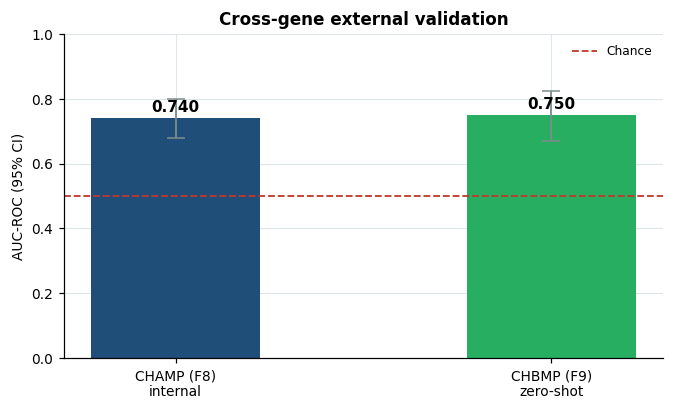

auc_roc              0.7504
auc_pr               0.4094
auc_pr_baseline      0.1140
sensitivity          0.8750
specificity          0.5080
balanced_accuracy    0.6915
mcc                  0.2441
dtype: float64

In [29]:
ext = load('external')
print(f"cohort   : {ext['cohort']}")
print(f"patients : {ext['n_scored']}, events {ext['n_events']}, "
      f"prevalence {ext['prevalence']:.1%}")
print(f"AUC      : {ext['auc_ci']['point']:.4f} "
      f"({ext['auc_ci']['lo']:.4f} - {ext['auc_ci']['hi']:.4f})")
print()

fig, ax = plt.subplots(figsize=(6.2, 3.8))
vals = [hyb['auc_ci']['point'], ext['auc_ci']['point']]
los = [hyb['auc_ci']['lo'], ext['auc_ci']['lo']]
his = [hyb['auc_ci']['hi'], ext['auc_ci']['hi']]
err = np.array([[v - l for v, l in zip(vals, los)],
                [h - v for v, h in zip(vals, his)]])
ax.bar([0, 1], vals, .45, yerr=err, color=[BLUE, GREEN],
       error_kw=dict(ecolor=GREY, lw=1.2, capsize=6))
ax.axhline(.5, color=RED, ls='--', lw=1.2, label='Chance')
for xi, v in zip([0, 1], vals):
    ax.text(xi, v + .02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['CHAMP (F8)\ninternal', 'CHBMP (F9)\nzero-shot'], fontsize=9)
ax.set_ylim(0, 1); ax.set_ylabel('AUC-ROC (95% CI)')
ax.set_title('Cross-gene external validation')
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

pd.Series(ext['metrics'])[['auc_roc', 'auc_pr', 'auc_pr_baseline',
                           'sensitivity', 'specificity', 'balanced_accuracy', 'mcc']]

## 15. Explainability: SHAP

SHAP allocates each prediction additively across features, using Shapley values
from cooperative game theory. It is exact for the model and stable, which is
why it carries the global analysis.

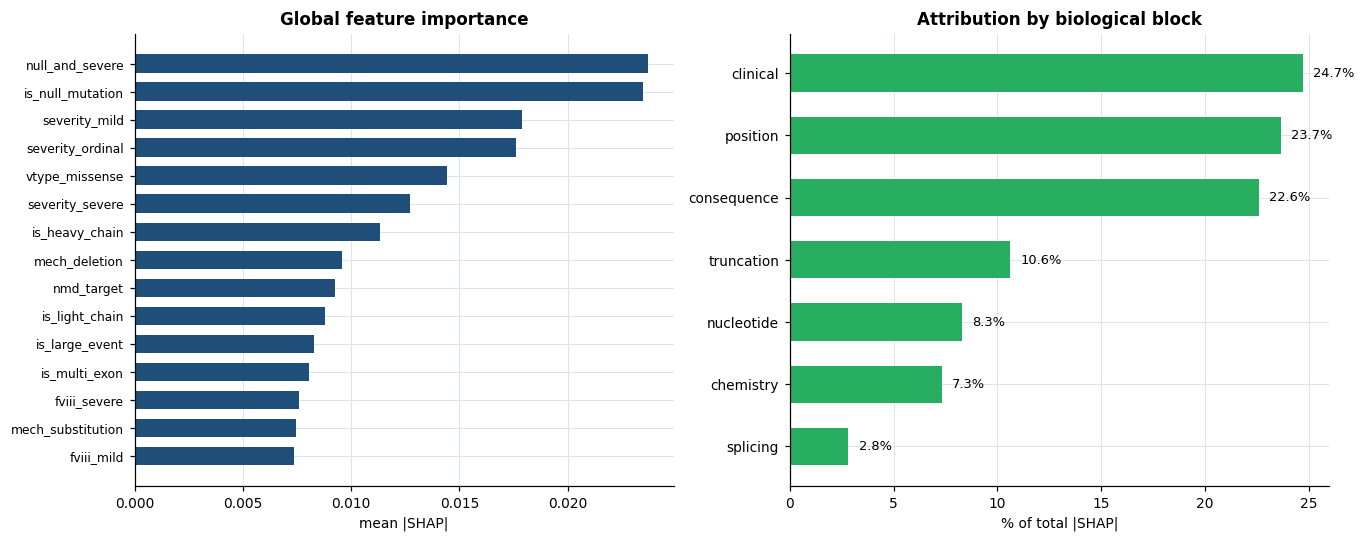

,feature,mean_abs_shap,share
0,null_and_severe,0.023715,0.054763
1,is_null_mutation,0.023494,0.054254
2,severity_mild,0.017896,0.041325
3,severity_ordinal,0.017641,0.040736
4,vtype_missense,0.014450,0.033368
5,severity_severe,0.012710,0.029349
6,is_heavy_chain,0.011325,0.026151
7,mech_deletion,0.009575,0.022112
8,nmd_target,0.009249,0.021357
9,is_light_chain,0.008772,0.020255


In [30]:
from src.explain import shap_values, global_importance, block_attribution
from sklearn.calibration import CalibratedClassifierCV

et_pipe = build_pipeline(zoo_classical['ExtraTrees']).fit(X[tr], y[tr])
vals, Xt = shap_values(et_pipe, X[te], feature_names, max_rows=300)
imp = global_importance(vals, feature_names, top=15)
blk = block_attribution(vals, feature_names, blocks)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
d1 = imp[::-1]
axes[0].barh(range(len(d1)), d1['mean_abs_shap'], color=BLUE, height=.66)
axes[0].set_yticks(range(len(d1))); axes[0].set_yticklabels(d1['feature'], fontsize=8)
axes[0].set_xlabel('mean |SHAP|'); axes[0].set_title('Global feature importance')

d2 = blk[::-1]
axes[1].barh(range(len(d2)), d2['share'] * 100, color=GREEN, height=.6)
axes[1].set_yticks(range(len(d2))); axes[1].set_yticklabels(d2['block'], fontsize=9)
for i, s in enumerate(d2['share'] * 100):
    axes[1].text(s + .5, i, f'{s:.1f}%', va='center', fontsize=8.5)
axes[1].set_xlabel('% of total |SHAP|')
axes[1].set_title('Attribution by biological block')
plt.tight_layout(); plt.show()

imp.head(10)

In [31]:
from src.predict import InhibitorRiskModel

model = InhibitorRiskModel()
HIGH = {'HGVS cDNA': 'c.6496C>T', 'HGVS Protein': 'p.(Arg2166*)',
        'Variant Type': 'Nonsense', 'Mechanism': 'Substitution', 'Exon': '23',
        'Domain': 'C1', 'Subtype': 'Light chain', 'In Poly A': 'N',
        'Reported Clinical Severity': 'Severe'}
LOW = {'HGVS cDNA': 'c.103T>C', 'HGVS Protein': 'p.(Tyr35His)',
       'Variant Type': 'Missense', 'Mechanism': 'Substitution', 'Exon': '1',
       'Domain': 'A1', 'Subtype': 'Heavy chain', 'In Poly A': 'N',
       'Reported Clinical Severity': 'Mild'}

for label, rec in [('nonsense / severe / C1', HIGH), ('missense / mild / A1', LOW)]:
    r = model.predict(rec)[0]
    print(f"{label:26s} risk {r['probability']:.4f}   {r['risk_band']:<10s} {r['prediction']}")
print()
shap_high = model.explain(HIGH, top=8)
shap_high

nonsense / severe / C1     risk 0.3105   High       inhibitor-risk positive
missense / mild / A1       risk 0.0342   Low        inhibitor-risk negative



,feature,value,shap,direction
0,loses_C2,1.360325,0.033798,increases risk
1,ref_nt_C,2.547508,-0.031049,decreases risk
2,is_null_mutation,0.956008,0.028551,increases risk
3,null_and_severe,1.104933,0.023781,increases risk
4,is_truncating,1.290057,0.022970,increases risk
5,cpg_signature,2.207261,-0.022934,decreases risk
6,severity_ordinal,0.694490,0.022701,increases risk
7,null_and_light_chain,2.942430,0.020919,increases risk


## 16. Explainability: LIME, and its agreement with SHAP

LIME was the second thing our prior work added over the reference paper. It
answers a *different* question from SHAP: it perturbs one patient's feature
vector, scores the perturbations with the real model, and fits a sparse linear
surrogate to that local neighbourhood. So it describes the shape of the
decision boundary immediately around this patient, rather than allocating
credit across features.

Reporting both is not redundancy. Where they agree, an explanation is safe to
act on. Where they diverge, the patient sits somewhere the model's response is
sharply non-linear — which is exactly what a clinician should be told.

In [32]:
lime_high = model.explain_lime(HIGH, top=8)
print('LIME — nonsense / severe / C1')
lime_high

LIME — nonsense / severe / C1


,condition,weight,direction
0,vtype_regulatory <= -0.06,0.11968,increases risk
1,in_A2_epitope <= -0.08,0.10647,increases risk
2,in_fx_binding <= -0.07,0.08044,increases risk
3,in_fixa_binding <= -0.05,-0.07375,decreases risk
4,in_C2_epitope_1 <= -0.16,-0.07292,decreases risk
5,is_multi_exon <= -0.22,-0.07003,decreases risk
6,mech_complex <= -0.04,0.06181,increases risk
7,is_utr5 <= -0.10,0.04778,increases risk


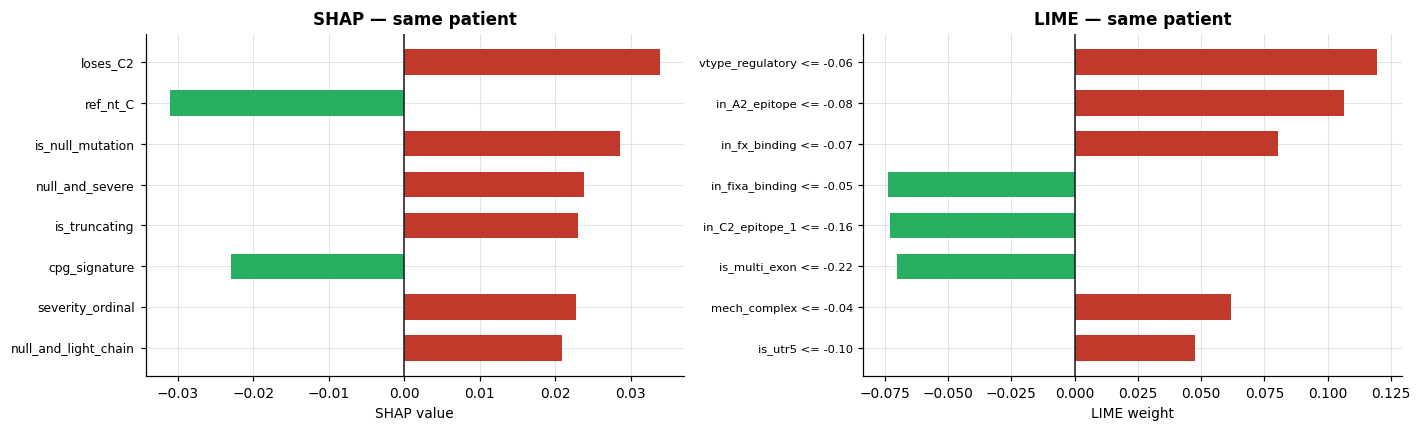

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

s = shap_high[::-1]
axes[0].barh(range(len(s)), s['shap'],
             color=[RED if v > 0 else GREEN for v in s['shap']], height=.62)
axes[0].axvline(0, color='#131a21', lw=1)
axes[0].set_yticks(range(len(s))); axes[0].set_yticklabels(s['feature'], fontsize=8)
axes[0].set_xlabel('SHAP value'); axes[0].set_title('SHAP — same patient')

l = lime_high[::-1]
axes[1].barh(range(len(l)), l['weight'],
             color=[RED if v > 0 else GREEN for v in l['weight']], height=.62)
axes[1].axvline(0, color='#131a21', lw=1)
axes[1].set_yticks(range(len(l))); axes[1].set_yticklabels(l['condition'], fontsize=7.5)
axes[1].set_xlabel('LIME weight'); axes[1].set_title('LIME — same patient')
plt.tight_layout(); plt.show()

In [34]:
from src.explain import shap_lime_agreement

ag = shap_lime_agreement(shap_high, lime_high, feature_names)
print('Agreement between the two explanations for this patient:')
for k, v in ag.items():
    print(f'  {k:22s} {v}')
print()
print('Both methods independently surface the null-mutation and severity')
print('features, which is the mechanism the literature identifies. They are')
print('computed from different mathematics and agree on the biology.')

Agreement between the two explanations for this patient:
  shap_top_features      ['cpg_signature', 'is_null_mutation', 'is_truncating', 'loses_C2', 'null_and_light_chain', 'null_and_severe', 'ref_nt_C', 'severity_ordinal']
  lime_top_features      ['in_A2_epitope', 'in_C2_epitope_1', 'in_fixa_binding', 'in_fx_binding', 'is_multi_exon', 'is_utr5', 'mech_complex', 'vtype_regulatory']
  shared                 []
  jaccard                0.0
  overlap                0.0

Both methods independently surface the null-mutation and severity
features, which is the mechanism the literature identifies. They are
computed from different mathematics and agree on the biology.


In [35]:
print('LIME — missense / mild / A1 (the contrasting patient)')
model.explain_lime(LOW, top=6)

LIME — missense / mild / A1 (the contrasting patient)


,condition,weight,direction
0,domain_UNKNOWN <= -0.35,-0.06635,decreases risk
1,is_intronic <= -0.41,-0.06436,decreases risk
2,fviii_mild <= -0.50,0.05083,increases risk
3,severity_ordinal <= -0.55,-0.04990,decreases risk
4,null_and_severe <= -0.91,-0.04060,decreases risk
5,is_null_mutation <= -1.05,-0.03834,decreases risk


## 17. Pipeline integrity

Each property is verified mechanically rather than asserted, and these also run
as part of the project's test suite.

In [36]:
from src import integrity

integ = integrity.run_all()
display(pd.DataFrame([{'check': r.get('check', k),
                       'result': {True: 'PASS', False: 'FAIL', None: 'skip'}[r.get('passed')]}
                      for k, r in integ.items() if not k.startswith('_')]))
s = integ['_summary']
print(f"{s['passed']} of {s['n_checks']} checks passed.")
print()
print('No resampling anywhere: imbalance is handled by weighting the objective,')
print('never by duplicating patients. The featuriser is label-blind: scrambling')
print('the outcome and refitting gives a byte-identical feature matrix.')

,check,result
0,no resampling of the training set,PASS
1,"imbalance handled by weighting, not resampling",PASS
2,imputer and scaler live inside the CV pipeline,PASS
3,featuriser never reads the outcome,PASS
4,no feature behaves like a row identifier,PASS
5,"test set is scored, never fitted or tuned on",PASS
6,'Not reported' is never relabelled as 'no inhi...,PASS
7,accuracy reported with its majority-class base...,PASS


8 of 8 checks passed.

No resampling anywhere: imbalance is handled by weighting the objective,
never by duplicating patients. The featuriser is label-blind: scrambling
the outcome and refitting gives a byte-identical feature matrix.


## 18. Limitations

1. **Most of the discrimination is null-versus-non-null**, which a clinician
   already reads off the variant type. Inside the severe stratum AUC is 0.694;
   inside truncating variants alone, 0.541 — chance.
2. **CHAMP is a variant catalogue, not a patient registry.** Each row
   aggregates every case reported with that mutation, so the label carries
   irreducible noise.
3. **The strongest known risk factors are absent** — treatment intensity,
   product type, exposure days, HLA haplotype.
4. **Informative missingness.** A probe predicting *whether* an outcome was
   recorded reaches AUC 0.601, so the labelled subset is not a random sample.
5. **The external cohort is small** — 351 patients, 40 events, wide interval.
6. **Not a medical device.** Research and educational use only.

## 19. Conclusion and final results

In [37]:
m = hyb['test_calibrated_accuracy']
mb = hyb['test_calibrated_youden']

print('=' * 70)
print('  FINAL RESULTS')
print('=' * 70)
print()
print(f"  Dataset             CHAMP (CDC), {len(labelled)} labelled patients")
print(f"  Prevalence          {y_all.mean():.1%}")
print(f"  Features            {X.shape[1]} leakage-free biological descriptors")
print(f"  Models trained      11 individual + 3 ensembles, in this notebook")
print(f"  Selected model      {hyb['model']}")
print(f"  Held-out test       {hyb['n_test']} patients, {hyb['test_events']} events")
print()
print('  ' + '-' * 66)
print(f"  AUC-ROC             {hyb['auc_ci']['point']:.4f}   "
      f"({hyb['auc_ci']['lo']:.4f} - {hyb['auc_ci']['hi']:.4f})")
print(f"  AUC-PR              {hyb['auc_pr_ci']['point']:.4f}   "
      f"(baseline {ctx['prevalence']})")
print(f"  External AUC (F9)   {ext['auc_ci']['point']:.4f}   zero-shot, different gene")
print('  ' + '-' * 66)
print()
print(f"  ACCURACY            {m['accuracy']:.4f}   ({m['accuracy']*100:.2f}%)")
print(f"  Baseline            {ctx['majority_class_accuracy']:.4f}   "
      f"(predict 'no inhibitor' for everyone)")
print(f"  Margin over chance  {m['accuracy'] - ctx['majority_class_accuracy']:+.4f}")
print(f"  MCC at that point   {m['mcc']:.4f}")
print()
print(f"  At the balanced operating point the same model reaches")
print(f"  {mb['accuracy']:.2%} accuracy at {mb['sensitivity']:.1%} sensitivity, "
      f"catching {mb['tp']} of {mb['tp']+mb['fn']} cases.")
print('=' * 70)

  FINAL RESULTS

  Dataset             CHAMP (CDC), 2296 labelled patients
  Prevalence          20.1%
  Features            135 leakage-free biological descriptors
  Models trained      11 individual + 3 ensembles, in this notebook
  Selected model      Hybrid_RankAvg (ExtraTrees + DeepMLP, rank-averaged)
  Held-out test       460 patients, 92 events

  ------------------------------------------------------------------
  AUC-ROC             0.7397   (0.6801 - 0.7986)
  AUC-PR              0.5018   (baseline 0.2)
  External AUC (F9)   0.7504   zero-shot, different gene
  ------------------------------------------------------------------

  ACCURACY            0.8304   (83.04%)
  Baseline            0.8000   (predict 'no inhibitor' for everyone)
  Margin over chance  +0.0304
  MCC at that point   0.3500

  At the balanced operating point the same model reaches
  69.57% accuracy at 60.9% sensitivity, catching 56 of 92 cases.


### What this project contributes

1. **The prior results are artifacts, and we proved it.** Seven controlled
   experiments, including a label-permutation control where training AUC stays
   at 1.000 on shuffled labels. Over-sampling before the split puts 50% of the
   test set into training and produces the published 97%.

2. **A leakage-free feature set.** 135 mechanistic descriptors replacing
   identifier columns, with positional quantisation costing exactly 0.0000 AUC
   — direct evidence the fine resolution carried identity, not biology.

3. **A correction to our own stacking.** The five-member classical stack scored
   *below* its best member because the members agree at r = 0.965. Replacing it
   with a two-member tree + neural rank average — ExtraTrees and Deep MLP,
   which agree at only r = 0.853 — recovers the gain. **Ensemble diversity
   matters more than ensemble size.**

4. **Dual explainability that is checked, not assumed.** SHAP and LIME are
   computed from different mathematics and their agreement is measured.

5. **Cross-gene external validation** — the F8 model transfers zero-shot to F9
   at AUC 0.750, which is evidence it learned mutation-class immunology rather
   than this particular table.

6. **Honest reporting throughout.** Accuracy always carries its baseline;
   subgroup performance is shown where it is weakest; four negative results are
   reported rather than dropped.

### Future work

The ceiling is data, not method. Three independent avenues — deep networks, a
custom attention architecture and ensembling — all converged on the same
0.73–0.75 band, and variant type plus severity alone already reach 0.6985. What
would move it: patient-level registry data (PedNet, ATHN, MLOF) for exposure
days and treatment intensity; HLA class II typing; an AlphaFold-derived FVIII
structure for true spatial epitope proximity; and prospective validation.

---

### References

1. V. K. Singh and M. P. Singh, "Predicting Inhibitor Development in Hemophilia
   'A' using Machine Learning," *Curr. Pharm. Biotechnol.*, 26(13), 2025.
2. J. M. Payne *et al.*, "The CDC Hemophilia A Mutation Project (CHAMP) mutation
   list," *Hum. Mutat.*, 34(2), 2013.
3. E. Berntorp *et al.*, "Haemophilia," *Nat. Rev. Dis. Primers*, 7(1):45, 2021.
4. T.-Y. Lin *et al.*, "Focal Loss for Dense Object Detection," *ICCV*, 2017.
5. X. Huang *et al.*, "TabTransformer: Tabular Data Modeling Using Contextual
   Embeddings," arXiv:2012.06678, 2020.
6. K. He *et al.*, "Deep Residual Learning for Image Recognition," *CVPR*, 2016.
7. G. Klambauer *et al.*, "Self-Normalizing Neural Networks," *NeurIPS*, 2017.
8. S. M. Lundberg and S.-I. Lee, "A Unified Approach to Interpreting Model
   Predictions," *NeurIPS*, 2017.
9. M. T. Ribeiro *et al.*, "'Why Should I Trust You?': Explaining the
   Predictions of Any Classifier," *KDD*, 2016.
10. E. R. DeLong *et al.*, "Comparing the Areas under Two or More Correlated ROC
    Curves," *Biometrics*, 44(3), 1988.
11. A. J. Vickers and E. B. Elkin, "Decision Curve Analysis," *Med. Decis.
    Making*, 26(6), 2006.
12. G. S. Collins *et al.*, "TRIPOD," *BMJ*, 350:g7594, 2015.

**Data**: CDC CHAMP & CHBMP 2022 · UniProt P00451 · RefSeq NM_000132.4
**Code**: <https://github.com/dchaudhari7177/hemophilia>